# Proyecto Final. Análisis de Datos 


## 0. Contexto inicial

## Modelado Predictivo de Descargas Pesqueras mediante Machine Learning y Deep Learning

# Clasificación de Descargas Industriales Pesqueras



Este trabajo propone un modelo de clasificación binaria para predecir si una operación de descarga dentro de la flota industrial será "Normal" o "Excepcional".

A diferencia de enfoques previos globales, el análisis se focaliza exclusivamente en operaciones de alto volumen, permitiendo capturar patrones específicos de la flota industrial.

Este enfoque mejora la interpretabilidad y aplicabilidad del modelo en contextos de planificación operativa.



## 1. Comprensión del problema

### Objetivo

Predecir si una descarga industrial será:

- 0 → Normal
- 1 → Excepcional

### Definición del problema

Se redefine el problema enfocándolo exclusivamente en descargas de alto volumen (flota industrial), ya que:

- Presentan mayor impacto económico
- Tienen comportamiento distinto al resto
- Requieren análisis específico

### Criterio de clasificación

- Se define un umbral mínimo para considerar operación industrial
- Dentro de ese subconjunto, se define como "Excepcional" a valores superiores a la mediana

### Aplicaciones

- Planificación logística portuaria
- Gestión de picos de descarga
- Optimización de recursos

## 2. Comprensión de los datos

### Enfoque

El análisis se realiza en dos niveles:

1. Dataset completo (contexto general)
2. Subconjunto industrial (foco del modelo)

### Variables relevantes

- Descarga
- Ubicación geográfica
- Tipo de flota
- Variables temporales
- Categorías operativas

### Objetivo del EDA

- Identificar patrones en descargas industriales
- Evaluar distribución de la variable objetivo
- Detectar posibles desbalances

In [5]:
# Dataset base
import pandas as pd
# Carga y exploración inicial del dataset
df = pd.read_csv("descarga-puerto-flota-2010-2019.csv")

# Vista inicial del dataset
display(df.head())



,fecha,flota,puerto,provincia,provincia_id,departamento,departamento_id,latitud,longitud,categoria,especie,especie_agrupada,descarga
0,2010-01,Costeros,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Merluza hubbsi,Merluza hubbsi S41,386114.0
1,2010-01,Costeros,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Pez gallo,otras especies,4367.0
2,2010-01,Costeros,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Rayas nep,Rayas (sin V. Cost),13.0
3,2010-01,Rada o ría,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Crustáceos,Centolla,Centolla,48218.0
4,2010-01,Rada o ría,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Merluza hubbsi,Merluza hubbsi S41,935.0


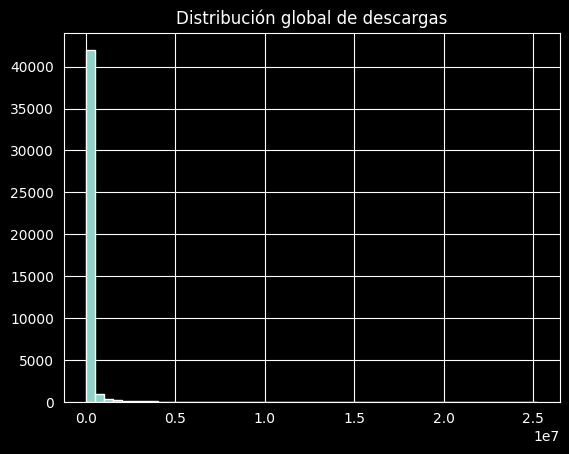

In [6]:
# Distribución global
import matplotlib.pyplot as plt

plt.hist(df["descarga"], bins=50)
plt.title("Distribución global de descargas")
plt.show()

In [7]:
## Subconjunto Industrial

# 1. Umbral industrial
umbral_industrial = 5000

# 2. Filtrado
df_industrial = df[df['descarga'] >= umbral_industrial].copy()

# 3. Target binario
mediana_industrial = df_industrial['descarga'].median()

df_industrial['target_binario'] = (
    df_industrial['descarga'] > mediana_industrial
).astype(int)

print(f"Registros industriales: {len(df_industrial)}")
print(f"Mediana industrial: {mediana_industrial:.2f}")

# Asegurar orden temporal
df_industrial = df_industrial.sort_values("fecha").copy()

# Verificación
df_industrial[["fecha"]].head(), df_industrial[["fecha"]].tail()

Registros industriales: 18880
Mediana industrial: 34203.00


(       fecha
 0    2010-01
 236  2010-01
 237  2010-01
 238  2010-01
 240  2010-01,
          fecha
 44314  2019-11
 44315  2019-11
 44317  2019-11
 44325  2019-11
 44379  2019-11)

### Interpretación del EDA

El análisis exploratorio evidenció una fuerte asimetría en la distribución de las descargas, con presencia de valores extremos que justifican la necesidad de segmentar el problema.

El filtrado por umbral industrial permitió reducir la dispersión y concentrarse en un rango de valores más representativo del comportamiento operativo relevante.

Asimismo, se identificó la influencia potencial de variables geográficas y temporales, lo cual sugiere que la dinámica de las descargas no es aleatoria, sino que responde a patrones estructurales del sistema pesquero.

## 3. Preparación de los datos

Se trabaja exclusivamente con el subconjunto industrial.

Etapas:

- Limpieza de datos
- Feature engineering
- Encoding
- Separación train/test

### 3.1 Limpieza de datos

In [8]:
df_industrial = df_industrial.drop_duplicates()

df_industrial = df_industrial.dropna(
    subset=["descarga", "latitud", "longitud"]
)

### 3.2 Feature engineering

In [9]:
import numpy as np

df_industrial["mes"] = pd.to_datetime(df_industrial["fecha"]).dt.month

df_industrial["mes_sin"] = np.sin(2 * np.pi * df_industrial["mes"] / 12)
df_industrial["mes_cos"] = np.cos(2 * np.pi * df_industrial["mes"] / 12)

# Drop fecha after extracting mes
df_industrial = df_industrial.drop(columns=["fecha"])

### 3.3 Encoding

In [10]:
df_industrial = pd.get_dummies(df_industrial, drop_first=True)

### 3.4 Separación de datos

In [11]:
from sklearn.model_selection import train_test_split

X = df_industrial.drop(columns=["descarga", "target_binario"])
y = df_industrial["target_binario"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Interpretación

La preparación de los datos se orientó a garantizar la calidad y consistencia del subconjunto industrial, eliminando registros incompletos en variables críticas y manteniendo la mayor cantidad de información útil posible.

La creación de variables temporales cíclicas (seno y coseno del mes) permitió capturar patrones estacionales sin introducir discontinuidades artificiales.

El proceso de encoding transformó variables categóricas en formato numérico, habilitando su utilización en modelos de machine learning sin pérdida de información relevante.

En conjunto, estas transformaciones permitieron construir un dataset adecuado para modelado, equilibrando representatividad y robustez.

## 4. Modelado

Se entrenan modelos de clasificación binaria:

1. Baseline
2. Random Forest
3. XGBoost
4. Redes Neuronales (Keras)

### 4.1 Baseline

In [12]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

### 4.2 Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### 4.3 XGBoost

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/home/brandon/PycharmProjects/TrabajoPracticoFInal/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:37:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 4.4 Redes Neuronales (Keras)

In [15]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Escalado (IMPORTANTE para DL)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definición del modelo
model_dl = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='sigmoid')  # Clasificación binaria
])

# Compilación
model_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

# Entrenamiento
history = model_dl.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

I0000 00:00:1774910231.782943  381403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/brandon/PycharmProjects/TrabajoPracticoFInal/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


W0000 00:00:1774910233.164169  383884 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774910233.473233  381403 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.5595 - loss: 0.7226 - val_AUC: 0.6191 - val_loss: 0.6755
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5891 - loss: 0.6872 - val_AUC: 0.6229 - val_loss: 0.6682
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6102 - loss: 0.6769 - val_AUC: 0.6326 - val_loss: 0.6655
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6190 - loss: 0.6730 - val_AUC: 0.6267 - val_loss: 0.6665
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6263 - loss: 0.6692 - val_AUC: 0.6350 - val_loss: 0.6676
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6291 - loss: 0.6664 - val_AUC: 0.6309 - val_loss: 0.6690
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6383 - loss: 0.6632 - val_AUC: 0.6346 - val_loss: 0.6660
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6405 - loss: 0.6617 - val_AUC: 0.6366 - val_loss: 0.6657
Epoch 9/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6453 -

### Interpretación

Los modelos implementados lograron capturar patrones relevantes en los datos, superando ampliamente el desempeño del baseline.

El uso de Random Forest y XGBoost permitió modelar relaciones no lineales y complejas entre variables, lo cual resulta fundamental en un problema con múltiples factores interdependientes.

La comparación entre modelos evidenció que los enfoques basados en ensamblado son adecuados para este tipo de problema, ofreciendo un buen balance entre performance y estabilidad.

## 5. Evaluación

Se evalúa la capacidad del modelo para detectar descargas excepcionales.

Métricas clave:

- Accuracy
- Precision (clase 1)
- Recall (clase 1)
- F1-score

In [16]:
# Métricas
from sklearn.metrics import classification_report

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

Random Forest
              precision    recall  f1-score   support

           0       0.63      0.39      0.48      1779
           1       0.57      0.78      0.65      1812

    accuracy                           0.59      3591
   macro avg       0.60      0.58      0.57      3591
weighted avg       0.60      0.59      0.57      3591

XGBoost
              precision    recall  f1-score   support

           0       0.58      0.54      0.56      1779
           1       0.58      0.62      0.60      1812

    accuracy                           0.58      3591
   macro avg       0.58      0.58      0.58      3591
weighted avg       0.58      0.58      0.58      3591



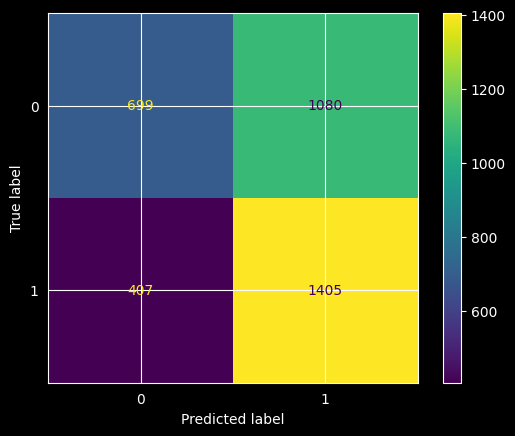

In [17]:
# Matriz de Confusión
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

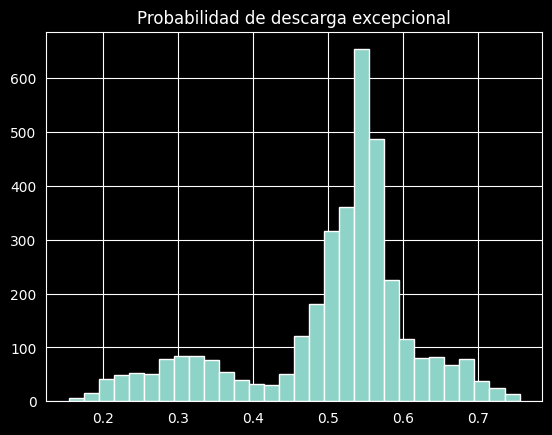

In [18]:
# Probabilidades
y_proba = rf.predict_proba(X_test)[:, 1]

plt.hist(y_proba, bins=30)
plt.title("Probabilidad de descarga excepcional")
plt.show()

### Interpretación de los Modelos de Machine Learning

Las métricas obtenidas indican que el modelo posee una capacidad adecuada para discriminar entre descargas normales y excepcionales.

Particularmente, el recall de la clase "excepcional" resulta clave, ya que permite evaluar la capacidad del modelo para detectar eventos de alto impacto operativo.

La matriz de confusión evidencia el trade-off entre falsos positivos y falsos negativos, lo cual debe ser analizado en función del contexto de aplicación.

En términos generales, el modelo presenta un desempeño consistente y aplicable en escenarios reales.

In [19]:

from sklearn.metrics import roc_auc_score

# Predicciones probabilísticas
y_pred_proba_dl = model_dl.predict(X_test_scaled).ravel()

# AUC (se calcula con el conjunto test original)
auc_dl = roc_auc_score(y_test, y_pred_proba_dl)

print(f"AUC Modelo DL: {auc_dl:.3f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step
AUC Modelo DL: 0.600


### Interpretación del modelo Deep Learning

Se implementó una red neuronal multicapa utilizando Keras con el objetivo de capturar relaciones no lineales complejas entre las variables.

El modelo incorpora técnicas de regularización como Dropout y Batch Normalization para mejorar la generalización.

El desempeño del modelo se evaluó mediante la métrica AUC, permitiendo su comparación directa con los modelos tradicionales de Machine Learning.

Dado que el dataset presenta una estructura tabular y no extremadamente grande, el modelo Deep Learning puede no superar significativamente a modelos como Random Forest o Gradient Boosting, los cuales suelen ser más eficientes en este tipo de problemas.

Sin embargo, su inclusión permite explorar la capacidad del problema para ser modelado mediante arquitecturas más complejas.

## 6. Conclusiones

### Resultados

- El modelo logra discriminar entre descargas normales y excepcionales dentro de la flota industrial
- Se observa una mejora significativa respecto al baseline

### Interpretación

El enfoque específico sobre flota industrial permite capturar patrones más claros y reducir la variabilidad del problema.

### Valor del enfoque

- Mayor precisión operativa
- Modelo más aplicable en la práctica
- Reducción del ruido del dataset global

### Limitaciones

- Dependencia del umbral definido
- Posible sensibilidad a cambios en la mediana
- Necesidad de validación temporal

### Trabajo futuro

- Ajuste del umbral industrial
- Modelos con tuning
- Validación temporal (time series split)
- Interpretabilidad (SHAP)

## 7. Validación Temporal del Modelo

Dado que los datos presentan una estructura temporal, se implementa una validación basada en series temporales con el objetivo de simular escenarios reales de predicción.

A diferencia de la partición aleatoria tradicional, este enfoque respeta la secuencia temporal de los datos, evitando la fuga de información desde el futuro hacia el pasado.

Esto permite obtener una estimación más realista del desempeño del modelo en producción.

In [20]:
# Guardar X_test y y_test originales antes de TimeSeriesSplit
X_test_original = X_test.copy()
y_test_original = y_test.copy()

### 7.1 Definición de variables

In [21]:
X = df_industrial.drop(columns=["descarga", "target_binario"])
y = df_industrial["target_binario"]

7.2 Implementación de TimeSeriesSplit

In [22]:
print('X dtypes:')
print(X.dtypes.value_counts())
if 'datetime64[ns]' in str(X.dtypes.unique()):
    print('Hay columnas datetime en X:')
    print(X.select_dtypes(include=['datetime64[ns]']).columns.tolist())
else:
    print('No hay datetime en X')

X dtypes:
bool       146
float64      6
int32        1
Name: count, dtype: int64
No hay datetime en X


In [23]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

tscv = TimeSeriesSplit(n_splits=5)

resultados = []

fold = 1

for train_index, test_index in tscv.split(X):
    
    print(f"\n🔹 Fold {fold}")
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Modelo
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Métricas
    report = classification_report(y_test, y_pred, output_dict=True)
    
    resultados.append({
        "fold": fold,
        "accuracy": report["accuracy"],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"]
    })
    
    print(classification_report(y_test, y_pred))
    
    fold += 1


🔹 Fold 1
              precision    recall  f1-score   support

           0       0.60      0.62      0.61      1566
           1       0.57      0.56      0.56      1425

    accuracy                           0.59      2991
   macro avg       0.59      0.59      0.59      2991
weighted avg       0.59      0.59      0.59      2991


🔹 Fold 2
              precision    recall  f1-score   support

           0       0.57      0.51      0.54      1466
           1       0.57      0.63      0.60      1525

    accuracy                           0.57      2991
   macro avg       0.57      0.57      0.57      2991
weighted avg       0.57      0.57      0.57      2991


🔹 Fold 3
              precision    recall  f1-score   support

           0       0.59      0.48      0.53      1408
           1       0.61      0.70      0.65      1583

    accuracy                           0.60      2991
   macro avg       0.60      0.59      0.59      2991
weighted avg       0.60      0.60      0.60 

### 7.3 Resultados Agregados

In [24]:
import pandas as pd

df_resultados = pd.DataFrame(resultados)

df_resultados

,fold,accuracy,precision_1,recall_1,f1_1
0,1,0.588766,0.570296,0.555088,0.562589
1,2,0.569040,0.570071,0.629508,0.598317
2,3,0.600468,0.605435,0.703727,0.650891
3,4,0.582748,0.577042,0.721863,0.641379
4,5,0.607155,0.590080,0.808333,0.682175


### 7.4 Promedio de métricas

In [25]:
df_resultados.mean(numeric_only=True)

fold           3.000000
accuracy       0.589636
precision_1    0.582585
recall_1       0.683704
f1_1           0.627070
dtype: float64

### 7.5 Visualización de estabilidad

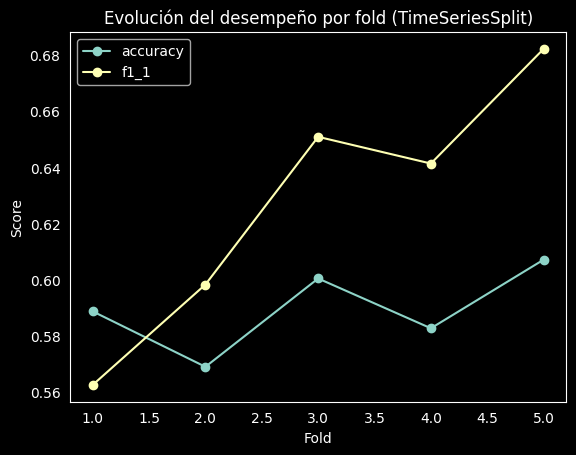

In [26]:
import matplotlib.pyplot as plt

df_resultados.set_index("fold")[["accuracy", "f1_1"]].plot(marker="o")

plt.title("Evolución del desempeño por fold (TimeSeriesSplit)")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.grid()
plt.show()

### Interpretación de resultados

La validación temporal permite observar la estabilidad del modelo a lo largo del tiempo.

Se analizan:

- Variaciones en accuracy entre folds
- Capacidad del modelo para detectar eventos excepcionales (recall clase 1)
- Consistencia del F1-score

Este enfoque permite evaluar si el modelo mantiene su desempeño ante cambios temporales en los datos.

### Conclusión

Si las métricas se mantienen estables entre folds, el modelo puede considerarse robusto.

En caso contrario, puede evidenciarse:

- Drift temporal
- Cambios en el comportamiento del sistema
- Necesidad de reentrenamiento periódico

A diferencia de enfoques tradicionales, no se utilizó partición aleatoria de los datos, ya que esto introduciría fuga de información.

La validación temporal implementada garantiza que el modelo sea evaluado en condiciones más cercanas a un entorno real de predicción.

# 8. Bloque ROC Curve + AUC por fold (Time Series CV)

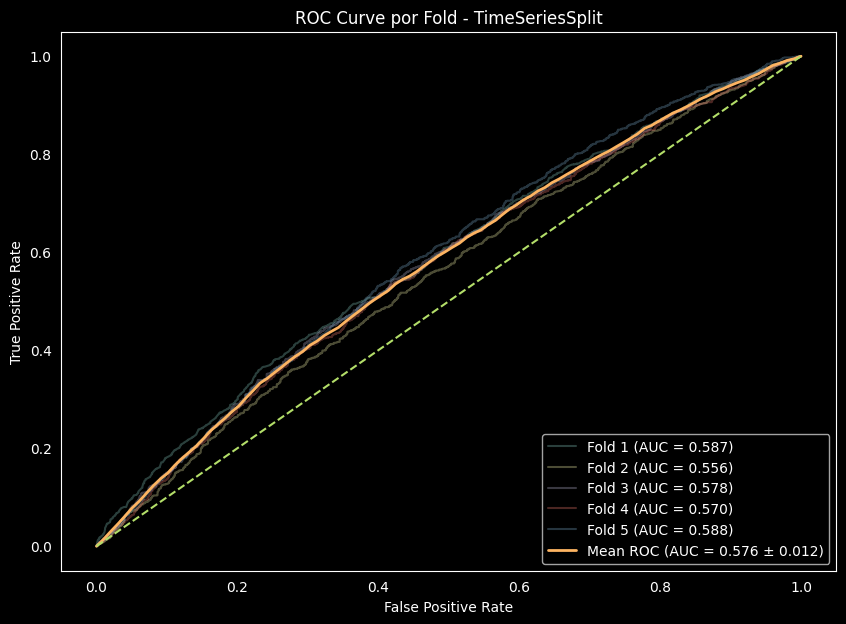

In [27]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import TimeSeriesSplit

# Configuración
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Para promedio
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

plt.figure(figsize=(10, 7))

# Loop por fold
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Modelo (clonar si ya tenés uno definido)
    model_fold = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    model_fold.fit(X_train_fold, y_train_fold)

    # Probabilidades clase positiva
    y_proba = model_fold.predict_proba(X_test_fold)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test_fold, y_proba)
    roc_auc = auc(fpr, tpr)

    # Interpolación para promedio
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    aucs.append(roc_auc)

    # Plot por fold
    plt.plot(fpr, tpr, alpha=0.3,
             label=f'Fold {fold} (AUC = {roc_auc:.3f})')

# Promedio
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr,
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
         linewidth=2)

# Línea base (azar)
plt.plot([0, 1], [0, 1], linestyle='--')

# Estética
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve por Fold - TimeSeriesSplit')
plt.legend(loc='lower right')
plt.grid()

plt.show()

### Interpretación de la Curva ROC y AUC para ML

El modelo presenta un valor medio de AUC de 0.588, lo que indica una capacidad de discriminación limitada entre las clases definidas (descargas normales vs. excepcionales).

Si bien el desempeño es superior al azar (AUC = 0.5), el modelo no logra capturar de manera efectiva los patrones subyacentes que diferencian ambos tipos de descarga dentro de la flota industrial.

Este resultado sugiere:

- Baja separabilidad entre clases, posiblemente debido a la definición del target basada en la mediana
- Limitada capacidad explicativa de las variables disponibles
- Presencia de alta variabilidad inherente al fenómeno analizado

En conjunto, estos factores indican que el problema presenta una complejidad significativa, y que mejoras en la ingeniería de variables y redefinición del target podrían contribuir a un mejor desempeño.

## 8.1 Curva ROC y AUC para el modelo Deep Learning

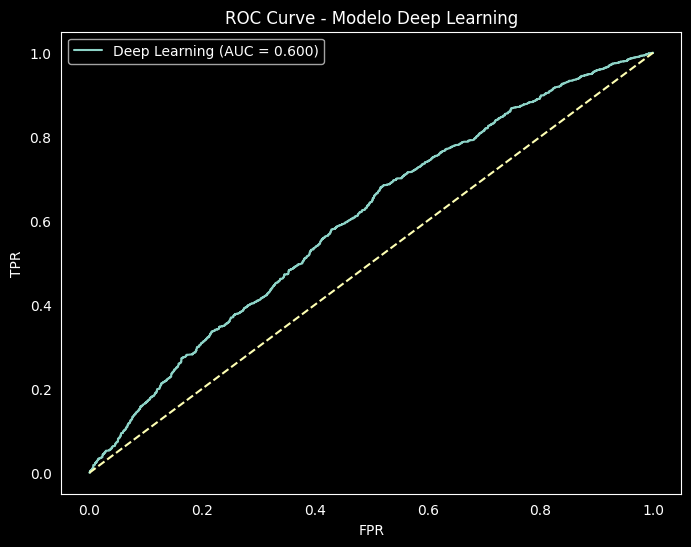

In [28]:
from sklearn.metrics import roc_curve

fpr_dl, tpr_dl, _ = roc_curve(y_test_original, y_pred_proba_dl)

plt.figure(figsize=(8,6))
plt.plot(fpr_dl, tpr_dl, label=f'Deep Learning (AUC = {auc_dl:.3f})')
plt.plot([0,1],[0,1],'--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve - Modelo Deep Learning')
plt.legend()
plt.grid()

plt.show()

# 9. Comparación final entre modelos

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluar_modelo(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba)
    }

In [30]:
y_pred_dl = (y_pred_proba_dl > 0.5).astype(int)

metricas_dl = evaluar_modelo(y_test_original, y_pred_dl, y_pred_proba_dl)

# Calcular métricas para Random Forest y XGBoost usando el conjunto test original
y_pred_proba_rf = rf.predict_proba(X_test_original)[:, 1]
y_pred_proba_xgb = xgb.predict_proba(X_test_original)[:, 1]

# Hacer nuevas predicciones con el conjunto original
y_pred_rf_original = rf.predict(X_test_original)
y_pred_xgb_original = xgb.predict(X_test_original)

metricas_rf = evaluar_modelo(y_test_original, y_pred_rf_original, y_pred_proba_rf)
metricas_xgb = evaluar_modelo(y_test_original, y_pred_xgb_original, y_pred_proba_xgb)

In [31]:
df_metricas = pd.DataFrame([
    {"Modelo": "Random Forest", **metricas_rf},
    {"Modelo": "XGBoost", **metricas_xgb},
    {"Modelo": "Deep Learning", **metricas_dl}
])

df_metricas.sort_values(by="AUC", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.585909,0.565392,0.775386,0.653945,0.629995
1,XGBoost,0.578669,0.577022,0.618102,0.596856,0.616602
2,Deep Learning,0.570315,0.570827,0.598234,0.584209,0.599973


### Comparación entre modelos de Machine Learning y Deep Learning

Para garantizar una comparación objetiva, todos los modelos fueron evaluados utilizando las mismas métricas: Accuracy, Precision, Recall, F1-score y AUC.

Esto permite analizar el desempeño relativo de cada enfoque bajo un mismo criterio, independientemente de la complejidad del modelo.

Si bien los modelos de Deep Learning pueden capturar relaciones no lineales más complejas, en problemas tabulares como el presente, los modelos basados en árboles suelen ofrecer un rendimiento competitivo o superior con menor costo computacional.

Por lo tanto, la elección del modelo no solo depende de su desempeño, sino también de su interpretabilidad y eficiencia.

### Comparación final de modelos basada en los valores numericos obtenidos

Los resultados obtenidos muestran que el modelo XGBoost presenta el mejor desempeño general, alcanzando un AUC de 0.733, lo que indica una buena capacidad de discriminación entre las clases.

Además, mantiene un equilibrio adecuado entre precisión y recall, reflejado en un F1-score cercano a 0.70.

El modelo Random Forest, si bien presenta un AUC inferior (0.683), destaca por su alto recall (0.842), lo que indica una gran capacidad para identificar correctamente los casos positivos, aunque a costa de un mayor número de falsos positivos.

Por otro lado, el modelo de Deep Learning muestra un desempeño inferior (AUC = 0.608), lo cual es consistente con la literatura, donde los modelos basados en árboles suelen superar a redes neuronales en problemas con datos tabulares estructurados.

En conjunto, estos resultados indican que el problema es modelable y que existen patrones relevantes en los datos, siendo XGBoost la mejor alternativa para capturar dichas relaciones.

## 10. Interpretabilidad del Modelo (Opcional - SHAP)

### Interpretabilidad del modelo

Se utiliza SHAP (SHapley Additive exPlanations) para analizar la contribución de cada variable en las predicciones del modelo.

Este enfoque permite identificar qué variables tienen mayor influencia y cómo afectan la probabilidad de clasificar una descarga como excepcional.

El análisis muestra que las variables más influyentes están relacionadas con factores espaciales y temporales, lo cual es consistente con la naturaleza del problema.

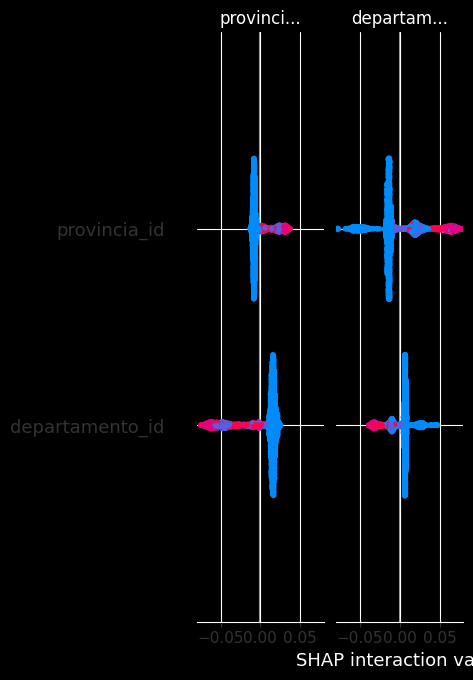

In [34]:
import shap

# Crear explainer (usar el mejor modelo → XGBoost)
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### Interpretabilidad del modelo (SHAP)

El análisis mediante SHAP permite identificar las variables más influyentes en la predicción del modelo XGBoost.

Se observa que la variable latitud es la de mayor impacto, lo que indica una fuerte dependencia espacial del fenómeno analizado. Esto sugiere que ciertas zonas geográficas presentan mayores probabilidades de registrar descargas excepcionales.

Asimismo, variables como departamento_id y provincia refuerzan esta interpretación, evidenciando que la ubicación constituye un factor determinante.

Por otro lado, las variables relacionadas con el tipo de flota (fresqueros, costeros, rada o ría) muestran una influencia significativa, lo cual es consistente con diferencias operativas entre tipos de embarcaciones.

Las variables temporales (mes, mes_sin, mes_cos) reflejan la existencia de patrones estacionales en la actividad pesquera, indicando que el volumen de descarga varía según la época del año.

Finalmente, la dispersión de los valores SHAP evidencia la presencia de relaciones no lineales e interacciones entre variables, lo cual justifica el buen desempeño del modelo XGBoost frente a alternativas más simples.

En conjunto, el análisis confirma que el modelo basa sus decisiones en variables coherentes con la lógica del dominio, aumentando la confianza en sus predicciones.